In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [8]:
avg_charges = df.groupby("smoker")["charges"].mean()

difference = (
    (avg_charges["yes"] - avg_charges["no"])
    / avg_charges["no"]
) * 100

difference

280.0001458298318

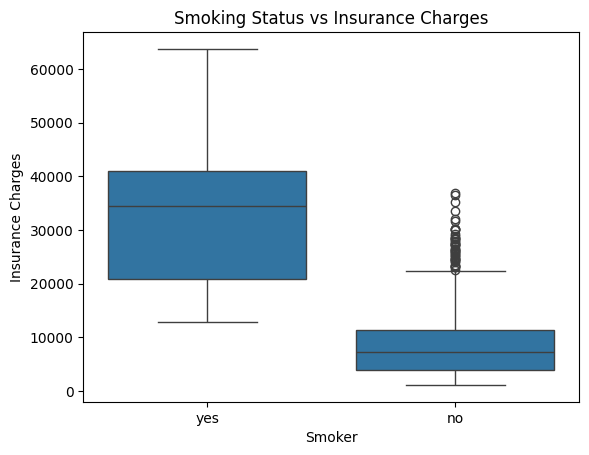

In [9]:
sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

### EDA Insight: Smoking Status

The average insurance charge for non-smokers is approximately
$8,434, while smokers have an average charge of approximately
$32,050.

Therefore, smokers have approximately 280% higher average
insurance charges than non-smokers in this dataset.

This indicates that smoking status is an important feature for
predicting insurance charges.

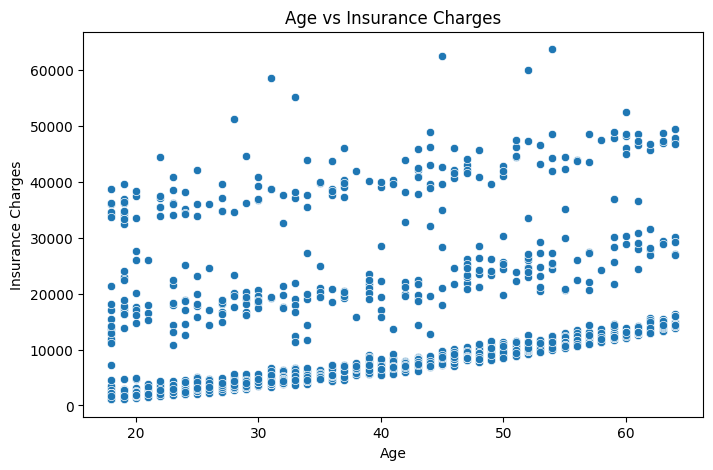

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

In [11]:
df["age"].corr(df["charges"])

0.29900819333064776

In [12]:
df["bmi"].corr(df["charges"])

0.1983409688336289

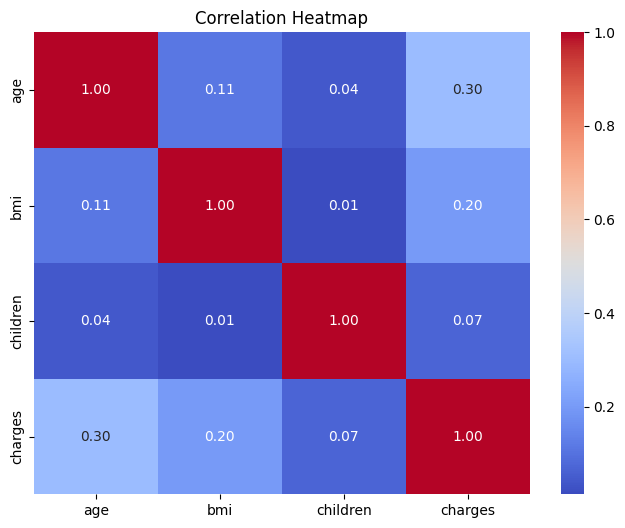

In [13]:
plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

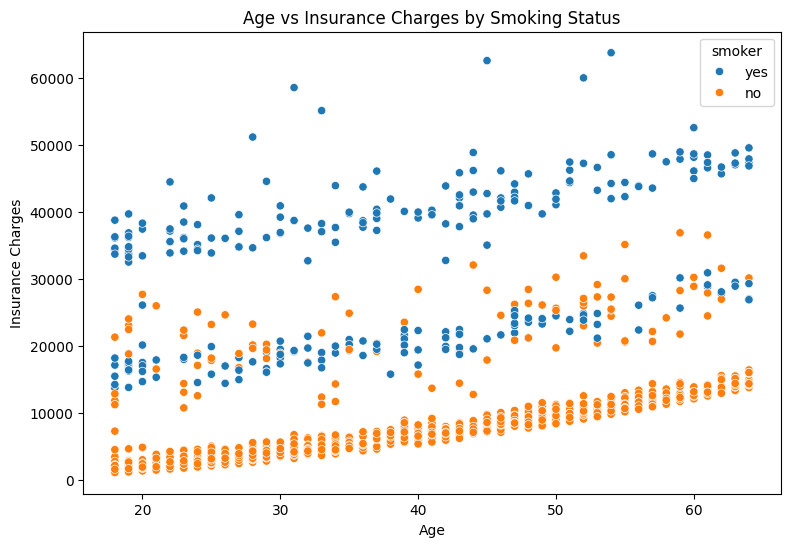

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

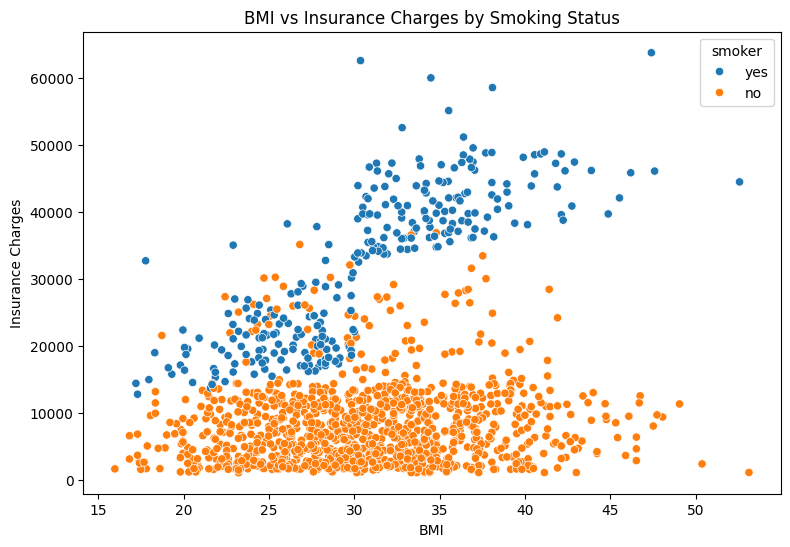

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

### EDA Insight: BMI and Smoking

BMI has a positive but relatively weak linear relationship with
insurance charges. The scatter plot shows that smoking status
creates a much clearer separation in insurance charges.

Non-smokers generally have lower charges, while smokers tend to
have substantially higher charges, particularly at higher BMI
values.

This suggests that the model should consider interactions between
features such as BMI and smoking status rather than relying on
individual features alone.

In [16]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [17]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [18]:
numerical_features = [
    "age",
    "bmi",
    "children"
]

In [19]:
categorical_features = [
    "sex",
    "smoker",
    "region"
]

In [20]:
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['age', 'bmi', 'children']
Categorical: ['sex', 'smoker', 'region']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1070, 6)
Testing data: (268, 6)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [27]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

(1070, 11)
(268, 11)


In [29]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_transformed, y_train)

LinearRegression()

In [30]:
y_pred_linear = linear_model.predict(X_test_transformed)

print(y_pred_linear[:5])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_linear
})

comparison.head(10)

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


In [32]:
from sklearn.metrics import r2_score, mean_squared_error

In [33]:
r2_linear = r2_score(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

print("Linear Regression R²:", r2_linear)
print("Linear Regression RMSE:", rmse_linear)

Linear Regression R²: 0.7835929767120724
Linear Regression RMSE: 5796.284659276272


In [34]:
y_pred_linear = linear_model.predict(X_test_transformed)

RANDOM FOREST

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [37]:
rf_model.fit(X_train_transformed, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [38]:
y_pred_rf = rf_model.predict(X_test_transformed)

In [39]:
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

print("Random Forest R²:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R²: 0.8631962114597633
Random Forest RMSE: 4608.537146876497


Gradient Boosting


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

In [41]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [42]:

gb_model.fit(X_train_transformed, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [43]:
y_pred_gb = gb_model.predict(X_test_transformed)

In [44]:
r2_gb = r2_score(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

print("Gradient Boosting R²:", r2_gb)
print("Gradient Boosting RMSE:", rmse_gb)

Gradient Boosting R²: 0.8800545571603235
Gradient Boosting RMSE: 4315.249453864607


In [45]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [47]:
from sklearn.pipeline import Pipeline

In [48]:
final_model = Pipeline([
    ("preprocessor", final_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [49]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [50]:
final_predictions = final_model.predict(X_test)

final_r2 = r2_score(y_test, final_predictions)
final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

print("Final Model R²:", final_r2)
print("Final Model RMSE:", final_rmse)

Final Model R²: 0.8800545571603235
Final Model RMSE: 4315.249453864607


In [51]:
import joblib

joblib.dump(final_model, "../model.pkl")

['../model.pkl']

In [54]:
import joblib

loaded_model = joblib.load("../model.pkl")

In [55]:
test_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Actual charge:", y_test.iloc[0])
print("Predicted charge:", test_prediction[0])

Actual charge: 9095.06825
Predicted charge: 11109.642366938555
